# Chapter 8: Data processing excercise


In this lesson we will be using a number of things we have learned in previous lessons. Try to go back to those lessons/notebooks to solve each part of the assignement.

P.S. you can also search the internet/cheat sheets to find the appropriate code for what you want to do. 

Before we start, let's load our favourite libraries.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns; sns.set()

## 8.1 Data & pre-processing

The data we will be using for this assignment is the IMDb dataset. IMDb (Internet Movie Database) contains information on almost all movies ever made. All these movies receive ratings from the public and from critics. 

There are 2 datasets, 'IMDb movies.csv' and 'IMDb ratings.csv'. The names are self-explanatory.

Before diving in, let's get familiar with our data. Like checking a recipe before cooking, we'll look at the structure and any potential issues.

### 8.1.1 Data Loading

Load both datasets correctly. Show the top 5 rows of both datasets.

Here, we use `pd.read_csv()` with `sep=","` to specify the comma separator (common for CSV files). This tells pandas how to split the data into columns, like using a knife to cut ingredients.

In [2]:
films_df = pd.read_csv("IMDb movies.csv", sep = ",")
films_df.head()

C:\Users\billo\AppData\Local\Temp\ipykernel_43032\861428385.py:1: DtypeWarning: Columns (3) have mixed types. Specify dtype option on import or set low_memory=False.
  films_df = pd.read_csv("IMDb movies.csv", sep = ",")


,imdb_title_id,title,original_title,year,date_published,genre,duration,country,language,director,...,actors,description,avg_vote,votes,budget,usa_gross_income,worlwide_gross_income,metascore,reviews_from_users,reviews_from_critics
0,tt0000009,Miss Jerry,Miss Jerry,1894,1894-10-09,Romance,45,USA,NaN,Alexander Black,...,"Blanche Bayliss, William Courtenay, Chauncey D...",The adventures of a female reporter in the 1890s.,5.9,154,NaN,NaN,NaN,NaN,1.0,2.0
1,tt0000574,The Story of the Kelly Gang,The Story of the Kelly Gang,1906,1906-12-26,"Biography, Crime, Drama",70,Australia,NaN,Charles Tait,...,"Elizabeth Tait, John Tait, Norman Campbell, Be...",True story of notorious Australian outlaw Ned ...,6.1,589,$ 2250,NaN,NaN,NaN,7.0,7.0
2,tt0001892,Den sorte drøm,Den sorte drøm,1911,1911-08-19,Drama,53,"Germany, Denmark",NaN,Urban Gad,...,"Asta Nielsen, Valdemar Psilander, Gunnar Helse...",Two men of high rank are both wooing the beaut...,5.8,188,NaN,NaN,NaN,NaN,5.0,2.0
3,tt0002101,Cleopatra,Cleopatra,1912,1912-11-13,"Drama, History",100,USA,English,Charles L. Gaskill,...,"Helen Gardner, Pearl Sindelar, Miss Fielding, ...",The fabled queen of Egypt's affair with Roman ...,5.2,446,$ 45000,NaN,NaN,NaN,25.0,3.0
4,tt0002130,L'Inferno,L'Inferno,1911,1911-03-06,"Adventure, Drama, Fantasy",68,Italy,Italian,"Francesco Bertolini, Adolfo Padovan",...,"Salvatore Papa, Arturo Pirovano, Giuseppe de L...",Loosely adapted from Dante's Divine Comedy and...,7.0,2237,NaN,NaN,NaN,NaN,31.0,14.0


In [3]:
ratings_df = pd.read_csv("IMDb ratings.csv", sep = ",")
ratings_df.head()

,imdb_title_id,weighted_average_vote,total_votes,mean_vote,median_vote,votes_10,votes_9,votes_8,votes_7,votes_6,...,females_30age_avg_vote,females_30age_votes,females_45age_avg_vote,females_45age_votes,top1000_voters_rating,top1000_voters_votes,us_voters_rating,us_voters_votes,non_us_voters_rating,non_us_voters_votes
0,tt0000009,5.9,154,5.9,6.0,12,4,10,43,28,...,5.7,13.0,4.5,4.0,5.7,34.0,6.4,51.0,6.0,70.0
1,tt0000574,6.1,589,6.3,6.0,57,18,58,137,139,...,6.2,23.0,6.6,14.0,6.4,66.0,6.0,96.0,6.2,331.0
2,tt0001892,5.8,188,6.0,6.0,6,6,17,44,52,...,5.8,4.0,6.8,7.0,5.4,32.0,6.2,31.0,5.9,123.0
3,tt0002101,5.2,446,5.3,5.0,15,8,16,62,98,...,5.5,14.0,6.1,21.0,4.9,57.0,5.5,207.0,4.7,105.0
4,tt0002130,7.0,2237,6.9,7.0,210,225,436,641,344,...,7.3,82.0,7.4,77.0,6.9,139.0,7.0,488.0,7.0,1166.0


### 8.1.0.5 Initial Data Checks

Before selecting columns, let's check for missing values and data types. This is like inspecting ingredients for quality before using them in a recipe. Missing data can cause errors later, so we address it early.

In [4]:
# Check data types and missing values for films_df
print("films_df dataset info:")
films_df.info()
print("\nMissing values in films_df:")
print(films_df.isnull().sum())

print("\n" + "="*50 + "\n")

# Check data types and missing values for ratings
print("ratings_df dataset info:")
ratings_df.info()
print("\nMissing values in ratings:")
print(ratings_df.isnull().sum())

films_df dataset info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 85855 entries, 0 to 85854
Data columns (total 22 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   imdb_title_id          85855 non-null  object 
 1   title                  85855 non-null  object 
 2   original_title         85855 non-null  object 
 3   year                   85855 non-null  object 
 4   date_published         85855 non-null  object 
 5   genre                  85855 non-null  object 
 6   duration               85855 non-null  int64  
 7   country                85791 non-null  object 
 8   language               84954 non-null  object 
 9   director               85768 non-null  object 
 10  writer                 84283 non-null  object 
 11  production_company     81400 non-null  object 
 12  actors                 85786 non-null  object 
 13  description            83740 non-null  object 
 14  avg_vote               85855 no

### 8.1.2 Data selection

There are a lot of variables but we do not need all of them. Keep only the following variables:

- movie data: 'imdb_title_id', 'title', 'year', 'genre', 'duration', 'country', 'language', 'avg_vote', 'votes'
- rating data: 'imdb_title_id', 'total_votes', 'weighted_average_vote', 'mean_vote', 'us_voters_rating', 'non_us_voters_rating'

How many rows and columns do we have remaining for each dataset?

In [5]:
films_df = films_df[["imdb_title_id", "title", "year", "genre", "duration", "country", "language", "avg_vote", "votes"]]
films_df.shape

(85855, 9)

In [6]:
ratings_df = ratings_df[["imdb_title_id", "total_votes", 'weighted_average_vote', 'mean_vote', 'us_voters_rating', 'non_us_voters_rating']]
ratings_df.shape

(85855, 6)

**Checkpoint:** You should have 85,855 rows × 6 columns for ratings. If not, review your column selection or check for loading issues (see Module 2).

### 8.1.3 Data cleaning

There is a movie with a wrong year. This will cause problems when fixing the dtypes of the data. Like a mislabeled ingredient, it can spoil the whole dish.

- What is the movie ID and title of that movie? 
- Fix the year!

*If you cannot figure this out, execute the next line of code and proceed for now. Do come back later to figure it out! **Note:** this line of code is not a solution for the problem, it simply avoids it.*

`films_df_merged = films_df_merged[films_df_merged['imdb_title_id'] !='tt8206668']`

In [ ]:
#films_df['year'].astype(int)

In [8]:
films_df[films_df['year'] == 'TV Movie 2019']

,imdb_title_id,title,year,genre,duration,country,language,avg_vote,votes
83917,tt8206668,Bad Education,TV Movie 2019,"Biography, Comedy, Crime",108,USA,English,7.1,23973


In [9]:
films_df.loc[ films_df['year'] == 'TV Movie 2019', "year"] = "2019"

In [10]:
films_df['year']

0        1894
1        1906
2        1911
3        1912
4        1911
         ... 
85850    2020
85851    2020
85852    2019
85853    2019
85854    2019
Name: year, Length: 85855, dtype: object

### 8.1.4 Data merging 

Merge both datasets into 1 DataFrame. Combine the dataframes in such a way that a movie needs to be in both datasets before it ends up in the final merged dataframe.

In [11]:
films_df_merged = pd.merge(films_df, ratings_df, how='inner', left_on='imdb_title_id', right_on='imdb_title_id')

In [12]:
films_df_merged.head()

,imdb_title_id,title,year,genre,duration,country,language,avg_vote,votes,total_votes,weighted_average_vote,mean_vote,us_voters_rating,non_us_voters_rating
0,tt0000009,Miss Jerry,1894,Romance,45,USA,NaN,5.9,154,154,5.9,5.9,6.4,6.0
1,tt0000574,The Story of the Kelly Gang,1906,"Biography, Crime, Drama",70,Australia,NaN,6.1,589,589,6.1,6.3,6.0,6.2
2,tt0001892,Den sorte drøm,1911,Drama,53,"Germany, Denmark",NaN,5.8,188,188,5.8,6.0,6.2,5.9
3,tt0002101,Cleopatra,1912,"Drama, History",100,USA,English,5.2,446,446,5.2,5.3,5.5,4.7
4,tt0002130,L'Inferno,1911,"Adventure, Drama, Fantasy",68,Italy,Italian,7.0,2237,2237,7.0,6.9,7.0,7.0


### 8.1.5 new variable

One of the most popular genre combinations is romantic comedies like Notting Hill, Love Actually and Pulp Fiction. 
Make a new variable which is true if there is 'romance' and 'comedy' in the genre. How many romantic comedies are there in the data?

In [13]:
films_df_merged['Romcom'] = False
films_df_merged.loc[np.logical_and(films_df_merged['genre'].str.contains('romance', case = False) , films_df_merged['genre'].str.contains('comedy', case = False) ), 'Romcom'] = True

In [14]:
films_df_merged['Romcom'].sum()

np.int64(6192)

In [15]:
films_df_merged[films_df_merged.Romcom == True]

,imdb_title_id,title,year,genre,duration,country,language,avg_vote,votes,total_votes,weighted_average_vote,mean_vote,us_voters_rating,non_us_voters_rating,Romcom
75,tt0006826,Hoodoo Ann,1916,"Comedy, Drama, Romance",65,USA,English,5.6,837,837,5.6,6.7,5.8,5.3,True
78,tt0007047,The Matrimaniac,1916,"Comedy, Romance",46,USA,English,6.0,573,573,6.0,6.7,6.5,5.7,True
113,tt0008775,Wild and Woolly,1917,"Comedy, Western, Romance",72,USA,English,6.4,557,557,6.4,6.8,6.6,6.3,True
114,tt0008827,Amarilly of Clothes-Line Alley,1918,"Comedy, Romance",67,USA,English,5.8,740,740,5.8,6.6,6.2,5.5,True
126,tt0009241,Johanna Enlists,1918,"Comedy, Romance",72,USA,English,5.1,594,594,5.1,6.5,5.5,5.0,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
85775,tt9816396,Kaguya-sama wa kokurasetai ~ Tensai tachi no r...,2019,"Comedy, Drama, Romance",113,Japan,Japanese,5.7,123,123,5.7,6.1,3.5,5.3,True
85782,tt9817760,Jai Mummy Di,2020,"Comedy, Drama, Romance",103,India,Hindi,3.6,661,661,3.6,3.9,3.8,3.7,True
85811,tt9860728,Falling Inn Love - Ristrutturazione con amore,2019,"Comedy, Romance",98,USA,English,5.6,14108,14108,5.6,5.7,5.8,5.5,True
85828,tt9886872,Munthiri Monchan,2019,"Comedy, Romance",130,India,Malayalam,8.1,990,990,8.1,8.8,3.4,4.9,True


### 8.1.6 Encoding & type checks

By checking the encoding we can check for unexpected things. Python loads large datasets in chunks (parts), and an unexpected data type could indicate something wrong. 

Check the encodings and list which ones need fixing. Fix them!

In [16]:
films_df_merged.dtypes

imdb_title_id             object
title                     object
year                      object
genre                     object
duration                   int64
country                   object
language                  object
avg_vote                 float64
votes                      int64
total_votes                int64
weighted_average_vote    float64
mean_vote                float64
us_voters_rating         float64
non_us_voters_rating     float64
Romcom                      bool
dtype: object

To fix:
year -> int



In [17]:
films_df_merged['year'] = films_df_merged['year'].astype('int')

In [18]:
films_df_merged.dtypes

imdb_title_id             object
title                     object
year                       int64
genre                     object
duration                   int64
country                   object
language                  object
avg_vote                 float64
votes                      int64
total_votes                int64
weighted_average_vote    float64
mean_vote                float64
us_voters_rating         float64
non_us_voters_rating     float64
Romcom                      bool
dtype: object

### 8.1.7 Genre Analysis

Movies often have multiple genres. Let's split them to see which genres are most common and how they relate to ratings. This is like unpacking a mixed bag of groceries to see what's inside.

In [19]:
# Split genres into separate rows for analysis
films_df_genres = films_df_merged.assign(genre=films_df_merged['genre'].str.split(', ')).explode('genre')
films_df_genres.head(10)

,imdb_title_id,title,year,genre,duration,country,language,avg_vote,votes,total_votes,weighted_average_vote,mean_vote,us_voters_rating,non_us_voters_rating,Romcom
0,tt0000009,Miss Jerry,1894,Romance,45,USA,NaN,5.9,154,154,5.9,5.9,6.4,6.0,False
1,tt0000574,The Story of the Kelly Gang,1906,Biography,70,Australia,NaN,6.1,589,589,6.1,6.3,6.0,6.2,False
1,tt0000574,The Story of the Kelly Gang,1906,Crime,70,Australia,NaN,6.1,589,589,6.1,6.3,6.0,6.2,False
1,tt0000574,The Story of the Kelly Gang,1906,Drama,70,Australia,NaN,6.1,589,589,6.1,6.3,6.0,6.2,False
2,tt0001892,Den sorte drøm,1911,Drama,53,"Germany, Denmark",NaN,5.8,188,188,5.8,6.0,6.2,5.9,False
3,tt0002101,Cleopatra,1912,Drama,100,USA,English,5.2,446,446,5.2,5.3,5.5,4.7,False
3,tt0002101,Cleopatra,1912,History,100,USA,English,5.2,446,446,5.2,5.3,5.5,4.7,False
4,tt0002130,L'Inferno,1911,Adventure,68,Italy,Italian,7.0,2237,2237,7.0,6.9,7.0,7.0,False
4,tt0002130,L'Inferno,1911,Drama,68,Italy,Italian,7.0,2237,2237,7.0,6.9,7.0,7.0,False
4,tt0002130,L'Inferno,1911,Fantasy,68,Italy,Italian,7.0,2237,2237,7.0,6.9,7.0,7.0,False


In [20]:
# Most common genres
print("Top 10 genres by movie count:")
print(films_df_genres['genre'].value_counts().head(10))

# Average rating by genre
print("\nAverage rating by genre (top 10):")
genre_ratings_df = films_df_genres.groupby('genre')['avg_vote'].mean().sort_values(ascending=False).head(10)
print(genre_ratings_df)

Top 10 genres by movie count:
genre
Drama        47110
Comedy       29368
Romance      14128
Action       12948
Thriller     11388
Crime        11067
Horror        9557
Adventure     7590
Mystery       5225
Family        3962
Name: count, dtype: int64

Average rating by genre (top 10):
genre
Documentary    7.300000
Film-Noir      6.644042
Biography      6.624022
History        6.543380
War            6.427520
News           6.400000
Animation      6.381317
Musical        6.247379
Music          6.243635
Drama          6.235876
Name: avg_vote, dtype: float64


### 8.1.8 movie countries

I think we all know Hollywood is the biggest movie scene in the world. But who is in second place? 

*Hint: Use the Country variable and not the language variable.*

In [21]:
films_df_merged['country'].value_counts()

country
USA                                                                      28511
India                                                                     6065
UK                                                                        4111
Japan                                                                     3077
France                                                                    3055
                                                                         ...  
Argentina, Brazil, France, Netherlands, Germany, Belgium, Switzerland        1
Germany, Belgium, Kosovo                                                     1
India, UK, Canada, USA                                                       1
Turkey, Germany, Romania                                                     1
Canada, USA, Ireland, South Africa                                           1
Name: count, Length: 4907, dtype: int64

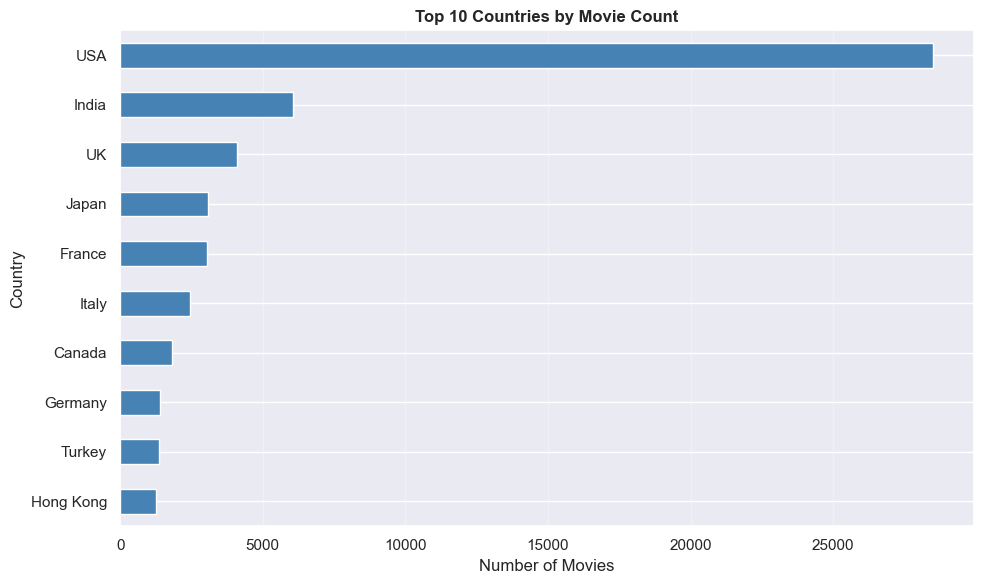

In [22]:
# Visualize top 10 countries by movie count
plt.figure(figsize=(10, 6))
country_counts = films_df_merged['country'].value_counts().head(10)
country_counts.sort_values().plot(kind='barh', color='steelblue')
plt.title('Top 10 Countries by Movie Count', fontsize=12, fontweight='bold')
plt.xlabel('Number of Movies')
plt.ylabel('Country')
plt.grid(True, alpha=0.3, axis='x')
plt.tight_layout()
plt.show()

### 8.1.9 Holywood movies


Let's focus on the 'Hollywood' movie scene, so select all movies from the USA.

Answer the following questions

1. What's the year of the oldest movie in the Hollywood data
2. What's the year of the youngest movie in this data

If there is only one oldest or youngest movie, give the name. If there are multiple, give the amount of movies.

In [23]:
films_df_merged = films_df_merged[films_df_merged['country'] == 'USA']

In [24]:
films_df_merged['language'].value_counts()

language
English                                        24831
English, Spanish                                 710
English, French                                  452
English, Italian                                 206
English, German                                  205
                                               ...  
English, French, Bulgarian, Hebrew, Aramaic        1
English, Min Nan, Mandarin                         1
English, Hindi, Bengali                            1
Spanish, English, Mandarin, French, Hindi          1
English, Russian, Sign Languages                   1
Name: count, Length: 649, dtype: int64

In [25]:
films_df_merged['year'].min()

1894

In [26]:
films_df_merged[films_df_merged['year']  == films_df_merged['year'].min()]

,imdb_title_id,title,year,genre,duration,country,language,avg_vote,votes,total_votes,weighted_average_vote,mean_vote,us_voters_rating,non_us_voters_rating,Romcom
0,tt0000009,Miss Jerry,1894,Romance,45,USA,NaN,5.9,154,154,5.9,5.9,6.4,6.0,False


In [27]:
films_df_merged[films_df_merged['year']  == films_df_merged['year'].min()].title

0    Miss Jerry
Name: title, dtype: object

In [28]:
films_df_merged['year'].max()

2020

In [29]:
len(films_df_merged[films_df_merged['year']  == films_df_merged['year'].max()])

276

## 8.2 Calculations 

In this section we are going to calculate some aggregate results per year and per decade. Specifically, we are interested in the average and standard deviation of the scores per year/decade. In this way we can hopefully answer the question which year/decade was rated the best for cinema. We are going to do this by writing a function that does these calculations for us

### 8.2.0 Standardize (Z-score) the movie scores 'avg_vote'

Use the formula and not some python pakage for this. i.e. you can use functions such as mean(), median(), min(), max, std(), IQR(), etc.

Save this data in a new variable named 'standardized_vote'

In [30]:
films_df_merged['standardized_vote'] = ( films_df_merged['avg_vote'] - films_df_merged['avg_vote'].mean() ) / films_df_merged['avg_vote'].std()

### 8.2.1 Write a function that calculates metrics per year

- Mean of 'avg_vote'
- Standard deviation of 'avg_vote'
- Mean of 'standardized_vote'
- Standard deviation of 'standardized_vote'
- Mean of 'duration'
- Standard deviation of 'duration'
- Total amount of movies

Use this function to answer the following questions:

1. In what year where most movies produced?
2. Which year had the highest average vote?
3. In what year were the standardized votes the least spread out?
4. Which year has the shortest movies?

In [31]:
def Aggregate_movie_data_per_year(films_df_merged):
    """
    Calculate aggregate movie statistics per year using groupby.
    Groupby is like sorting data into buckets before calculating, much faster than loops.
    """
    # Group by year and calculate aggregates
    agg_data = films_df_merged.groupby('year').agg(
        vote_avg=('avg_vote', 'mean'),
        vote_std=('avg_vote', 'std'),
        z_vote_avg=('standardized_vote', 'mean'),
        z_vote_std=('standardized_vote', 'std'),
        movie_length_avg=('duration', 'mean'),
        movie_length_std=('duration', 'std'),
        N_movies=('year', 'size'),  # Count of movies
        us_avg=('us_voters_rating', 'mean'),
        non_us_avg=('non_us_voters_rating', 'mean')
    ).reset_index()
    
    return agg_data

In [32]:
agg_films_df_year = Aggregate_movie_data_per_year(films_df_merged)
agg_films_df_year.head()

,year,vote_avg,vote_std,z_vote_avg,z_vote_std,movie_length_avg,movie_length_std,N_movies,us_avg,non_us_avg
0,1894,5.90000,NaN,0.267679,NaN,45.000000,NaN,1,6.400000,6.000000
1,1912,5.45000,0.353553,-0.082568,0.275180,80.000000,28.284271,2,5.700000,5.150000
2,1913,6.00000,NaN,0.345511,NaN,88.000000,NaN,1,6.100000,6.000000
3,1914,5.91875,0.405329,0.282273,0.315478,73.312500,35.254728,16,6.100000,5.812500
4,1915,6.26000,0.352136,0.547876,0.274077,74.066667,34.900812,15,6.273333,6.213333


In [33]:
agg_films_df_year[agg_films_df_year.N_movies == agg_films_df_year.N_movies.max()]

,year,vote_avg,vote_std,z_vote_avg,z_vote_std,movie_length_avg,movie_length_std,N_movies,us_avg,non_us_avg
106,2017,5.050276,1.265183,-0.393683,0.984724,92.98232,13.029991,905,5.22442,4.771381


In [34]:
agg_films_df_year[agg_films_df_year.vote_avg == agg_films_df_year.vote_avg.max()]

,year,vote_avg,vote_std,z_vote_avg,z_vote_std,movie_length_avg,movie_length_std,N_movies,us_avg,non_us_avg
17,1928,6.716667,0.900878,0.903311,0.701177,84.15,15.973309,60,6.861667,6.513333


In [35]:
agg_films_df_year[agg_films_df_year.z_vote_std == agg_films_df_year.z_vote_std.min()]

,year,vote_avg,vote_std,z_vote_avg,z_vote_std,movie_length_avg,movie_length_std,N_movies,us_avg,non_us_avg
4,1915,6.26,0.352136,0.547876,0.274077,74.066667,34.900812,15,6.273333,6.213333


In [36]:
agg_films_df_year[agg_films_df_year.movie_length_avg == agg_films_df_year.movie_length_avg.min()]

,year,vote_avg,vote_std,z_vote_avg,z_vote_std,movie_length_avg,movie_length_std,N_movies,us_avg,non_us_avg
0,1894,5.9,NaN,0.267679,NaN,45.0,NaN,1,6.4,6.0


### 8.2.2 Adapt your function to calculates metrics per decade

Only consider decades up to the 2010's.

Keep the same variables as before. Use the new function to answer the same questions as 8.2.1. Do your answers change?

In [37]:
decades = list(range(1910,2020,10))
decades

[1910, 1920, 1930, 1940, 1950, 1960, 1970, 1980, 1990, 2000, 2010]

In [38]:
def Aggregate_movie_data_per_decade(films_df_merged, start_decade=1910, end_decade=2010):
    """
    Calculate aggregate movie statistics per decade using groupby.
    Decades are calculated by flooring year to nearest 10.
    """
    # Create decade column
    films_df_merged = films_df_merged.copy()
    films_df_merged['decade'] = (films_df_merged['year'] // 10) * 10
    
    # Filter to specified decades
    films_df_filtered = films_df_merged[(films_df_merged['decade'] >= start_decade) & (films_df_merged['decade'] <= end_decade)]
    
    # Group by decade and calculate aggregates
    agg_data = films_df_filtered.groupby('decade').agg(
        vote_avg=('avg_vote', 'mean'),
        vote_std=('avg_vote', 'std'),
        z_vote_avg=('standardized_vote', 'mean'),
        z_vote_std=('standardized_vote', 'std'),
        movie_length_avg=('duration', 'mean'),
        movie_length_std=('duration', 'std'),
        N_movies=('year', 'size')
    ).reset_index()
    
    return agg_data

In [39]:
agg_films_df_decade = Aggregate_movie_data_per_decade(films_df_merged)

In [40]:
agg_films_df_decade[agg_films_df_decade.N_movies == agg_films_df_decade.N_movies.max()]

,decade,vote_avg,vote_std,z_vote_avg,z_vote_std,movie_length_avg,movie_length_std,N_movies
10,2010,5.078277,1.34013,-0.371889,1.043057,93.666324,14.408041,7789


In [41]:
agg_films_df_decade[agg_films_df_decade.vote_avg == agg_films_df_decade.vote_avg.max()]

,decade,vote_avg,vote_std,z_vote_avg,z_vote_std,movie_length_avg,movie_length_std,N_movies
1,1920,6.462661,0.771049,0.705612,0.600127,84.88412,21.900937,466


In [42]:
agg_films_df_decade[agg_films_df_decade.z_vote_std == agg_films_df_decade.z_vote_std.min()]

,decade,vote_avg,vote_std,z_vote_avg,z_vote_std,movie_length_avg,movie_length_std,N_movies
0,1910,6.101681,0.6444,0.424652,0.501553,72.857143,24.939005,119


In [43]:
agg_films_df_decade[agg_films_df_decade.movie_length_avg == agg_films_df_decade.movie_length_avg.min()]

,decade,vote_avg,vote_std,z_vote_avg,z_vote_std,movie_length_avg,movie_length_std,N_movies
0,1910,6.101681,0.6444,0.424652,0.501553,72.857143,24.939005,119


## 8.3 Visualising results

### 8.3.1 Time Series Analysis

Explore how ratings, engagement, and voting patterns have evolved over time. This section reveals trends in the film industry and audience preferences across decades and years.

#### 8.3.1.1 Visualise the average scores (+/- SD) over time

Visualise the average scores per year. Also show the spread of each year's scores by showing the standard deviation.

*Hint: remember we are working with a linear passage of time...*

There is a high chance your data will look weird, if so: fix it.

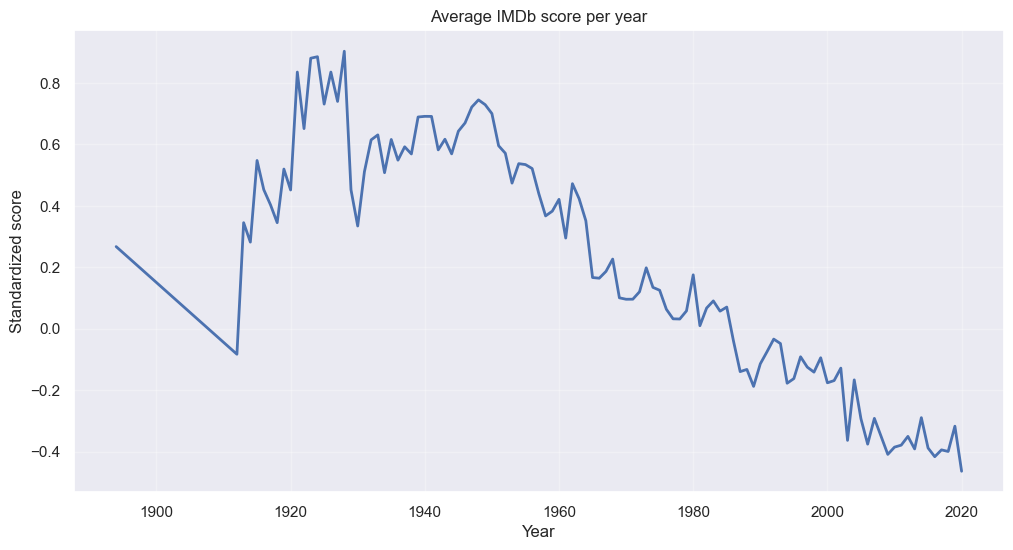

In [44]:
plt.figure(figsize=(12, 6))
plt.title("Average IMDb score per year")
plt.xlabel('Year')
plt.ylabel('Standardized score')
plt.plot(agg_films_df_year['year'], agg_films_df_year['z_vote_avg'], linewidth=2)
# Note: fill_between omitted due to NaN handling issues in unsorted data
plt.grid(True, alpha=0.3)
plt.show()

In [45]:
agg_films_df_year['year'] = agg_films_df_year['year'].astype(int)
agg_films_df_year.sort_values(by=['year'], inplace = True)

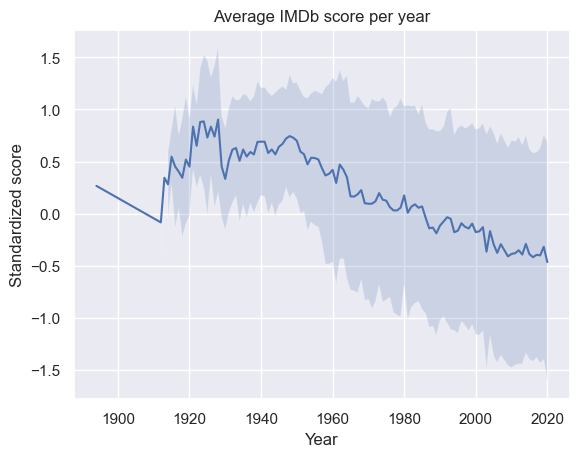

In [46]:
plt.figure()
plt.title("Average IMDb score per year");
plt.xlabel('Year')
plt.ylabel('Standardized score')
plt.plot(agg_films_df_year['year'], agg_films_df_year['z_vote_avg'])

z_vote_min = agg_films_df_year['z_vote_avg'] - agg_films_df_year['z_vote_std']
z_vote_max = agg_films_df_year['z_vote_avg'] + agg_films_df_year['z_vote_std']

plt.fill_between(agg_films_df_year['year'], z_vote_min, z_vote_max, alpha = 0.2)

#### 8.3.1.2 Visualise the average scores (+/- SD) over time, and add the decade based data as an errorbar visual.

*Hint: this is a new element to visualize your data, so do some research!*

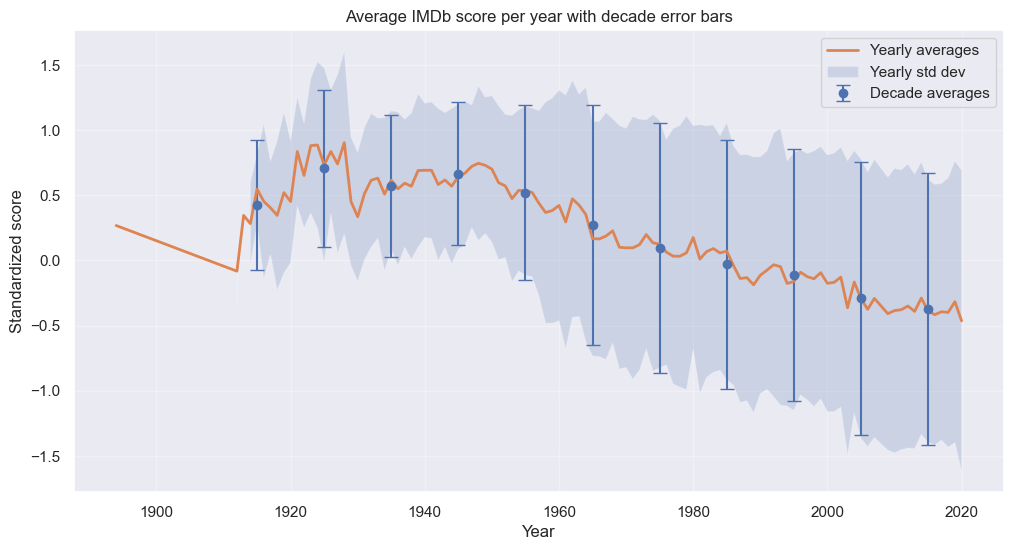

In [47]:
plt.figure(figsize=(12, 6))
plt.errorbar(agg_films_df_decade['decade'] + 5, agg_films_df_decade['z_vote_avg'], 
             yerr=agg_films_df_decade['z_vote_std'], fmt='o', capsize=5, label='Decade averages')
plt.title("Average IMDb score per year with decade error bars")
plt.xlabel('Year')
plt.ylabel('Standardized score')
plt.plot(agg_films_df_year['year'], agg_films_df_year['z_vote_avg'], linewidth=2, label='Yearly averages')

z_vote_min = agg_films_df_year['z_vote_avg'] - agg_films_df_year['z_vote_std']
z_vote_max = agg_films_df_year['z_vote_avg'] + agg_films_df_year['z_vote_std']

plt.fill_between(agg_films_df_year['year'], z_vote_min, z_vote_max, alpha=0.2, label='Yearly std dev')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

#### 8.3.1.3 Change the previous plot but plot US vs non-US votes.

You no longer need to show the standard deviation or decade errorplots.

Adjust your function to include this information.

In [48]:
def Aggregate_movie_data_per_year(films_df_merged):
    
    years = pd.unique(films_df_merged['year'])
    
    vote_avg = []
    vote_std = []
    z_vote_avg = []
    z_vote_std = []
    movie_length_avg = []
    movie_length_std = []
    N_movies = []
    us_avg = []
    non_us_avg = []
    
    for year in years:
        films_df_subset = films_df_merged[films_df_merged['year'] == year]
            
        vote_avg.append(films_df_subset['avg_vote'].mean())
        vote_std.append(films_df_subset['avg_vote'].std())
        
        z_vote_avg.append(films_df_subset['standardized_vote'].mean())
        z_vote_std.append(films_df_subset['standardized_vote'].std())
        
        movie_length_avg.append(films_df_subset['duration'].mean())
        movie_length_std.append(films_df_subset['duration'].std())
        
        N_movies.append(len(films_df_subset['year']))

        us_avg.append(films_df_subset['us_voters_rating'].mean())
        non_us_avg.append(films_df_subset['non_us_voters_rating'].mean())
        
        
    results = pd.DataFrame({'year': years,
                            'vote_avg': vote_avg,
                            'vote_std': vote_std,
                            'z_vote_avg': z_vote_avg,
                            'z_vote_std': z_vote_std,
                            'movie_length_avg': movie_length_avg,
                            'movie_length_std': movie_length_std,
                            'N_movies': N_movies,
                            'us_avg': us_avg,
                            'non_us_avg': non_us_avg})
    
    return(results)

In [49]:
agg_films_df_year = Aggregate_movie_data_per_year(films_df_merged)
agg_films_df_year.sort_values(by=['year'], inplace = True)

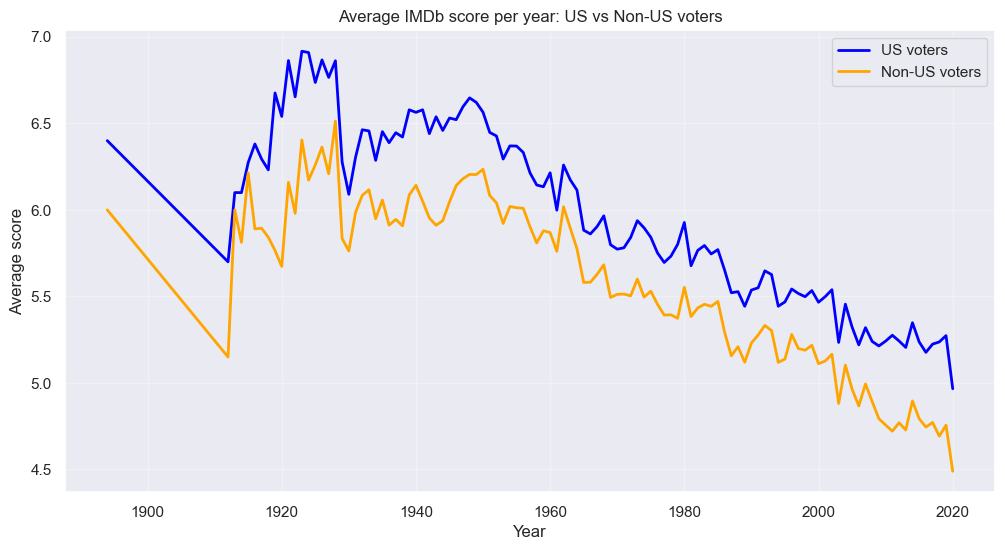

In [50]:
plt.figure(figsize=(12, 6))
plt.title("Average IMDb score per year: US vs Non-US voters")
plt.xlabel('Year')
plt.ylabel('Average score')
plt.plot(agg_films_df_year['year'], agg_films_df_year['us_avg'], linewidth=2, label='US voters', color='blue')
plt.plot(agg_films_df_year['year'], agg_films_df_year['non_us_avg'], linewidth=2, label='Non-US voters', color='orange')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

#### 8.3.1.4 Calculate the difference in rating between US votes and non-US votes

Create a function to calculate the difference in rating for each movie. Show this yearly difference in a histogram. Show the median and standard deviation.

In [51]:
def Rating_diff_per_year(films_df_merged):
    
    years = pd.unique(films_df_merged['year'])

    us_avg = []
    non_us_avg = []
    rating_diff_avg = []
    rating_diff_std = []
    
    for year in years:
        films_df_subset = films_df_merged[films_df_merged['year'] == year]

        us_avg.append(films_df_subset['us_voters_rating'].mean())
        non_us_avg.append(films_df_subset['non_us_voters_rating'].mean())

        rating_diff = films_df_subset['us_voters_rating'] - films_df_subset['non_us_voters_rating']
        rating_diff_avg.append(rating_diff.mean())
        rating_diff_std.append(rating_diff.std())
        
        
    results = pd.DataFrame({'year': years,
                            'us_avg': us_avg,
                            'non_us_avg': non_us_avg,
                            'rating_diff_avg': rating_diff_avg,
                            'rating_diff_std': rating_diff_std})
    
    return(results)

In [52]:
rating_diff_per_year = Rating_diff_per_year(films_df_merged)
rating_diff_per_year.sort_values(by=['year'], inplace = True)

Text(0, 0.5, 'Count')

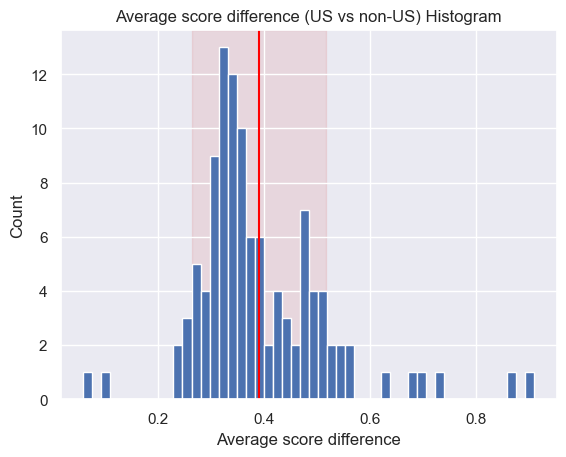

In [53]:
plt.hist(rating_diff_per_year['rating_diff_avg'], bins=50)
plt.axvline(rating_diff_per_year['rating_diff_avg'].mean(), label = "mean", color = "red")
plt.axvspan(
    rating_diff_per_year['rating_diff_avg'].mean() - rating_diff_per_year['rating_diff_avg'].std(),
    rating_diff_per_year['rating_diff_avg'].mean() + rating_diff_per_year['rating_diff_avg'].std(),
    zorder = 0, color = 'tab:red', alpha = 0.1)
plt.title("Average score difference (US vs non-US) Histogram");
plt.xlabel('Average score difference')
plt.ylabel('Count')

#### 8.3.1.5 Show the difference in rating between US votes and non-US votes on a plot

Show the calculated difference on a plot. Also show the standard deviation per year.

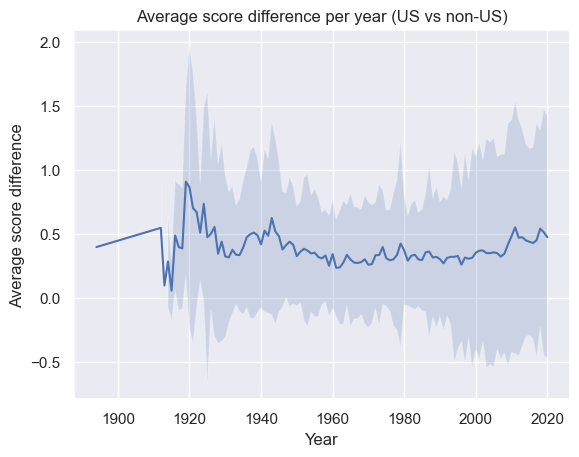

In [54]:
plt.figure()
plt.title("Average score difference per year (US vs non-US)");
plt.xlabel('Year')
plt.ylabel('Average score difference')
plt.plot(rating_diff_per_year['year'], rating_diff_per_year['rating_diff_avg'])

rating_diff_min = rating_diff_per_year['rating_diff_avg'] - rating_diff_per_year['rating_diff_std']
rating_diff_max = rating_diff_per_year['rating_diff_avg'] + rating_diff_per_year['rating_diff_std']

plt.fill_between(rating_diff_per_year['year'], rating_diff_min, rating_diff_max, alpha = 0.2)

### 8.3.2 Categorical Analysis: Genre & Language

Analyze how different categories (genres and languages) influence movie ratings and production volume. By breaking down the data by these categorical variables, we can discover which genres resonate most with audiences and whether production language affects quality perception.

#### 8.3.2.1 Movie count by genre

Which genres dominate the Hollywood film industry? Understanding genre distribution helps us see which genres studios prioritize and which markets have the most content.

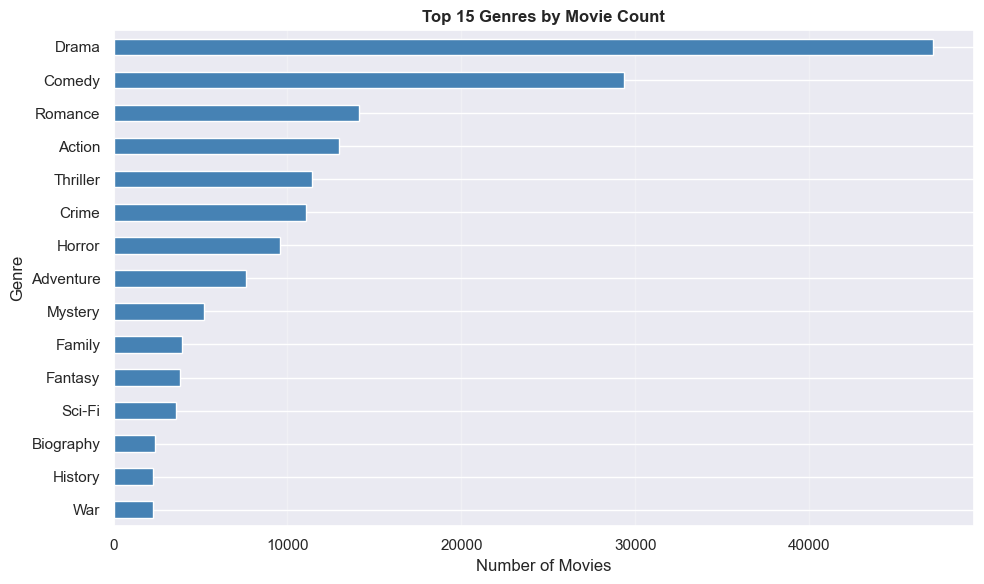

Total unique genres: 25

Top 5 most common genres:
genre
Drama       47110
Comedy      29368
Romance     14128
Action      12948
Thriller    11388
Name: count, dtype: int64


In [55]:
# Movie count by genre (top 15)
genre_counts = films_df_genres['genre'].value_counts().head(15)

plt.figure(figsize=(10, 6))
genre_counts.sort_values().plot(kind='barh', color='steelblue')
plt.title('Top 15 Genres by Movie Count', fontsize=12, fontweight='bold')
plt.xlabel('Number of Movies')
plt.ylabel('Genre')
plt.grid(True, alpha=0.3, axis='x')
plt.tight_layout()
plt.show()

print(f"Total unique genres: {films_df_genres['genre'].nunique()}")
print(f"\nTop 5 most common genres:\n{films_df_genres['genre'].value_counts().head()}")

#### 8.3.2.2 Average rating by genre

Does popularity equal quality? Some genres may be produced more often but receive lower ratings. Others might be rarer but highly acclaimed. This comparison reveals which genres deliver the most consistent audience satisfaction.

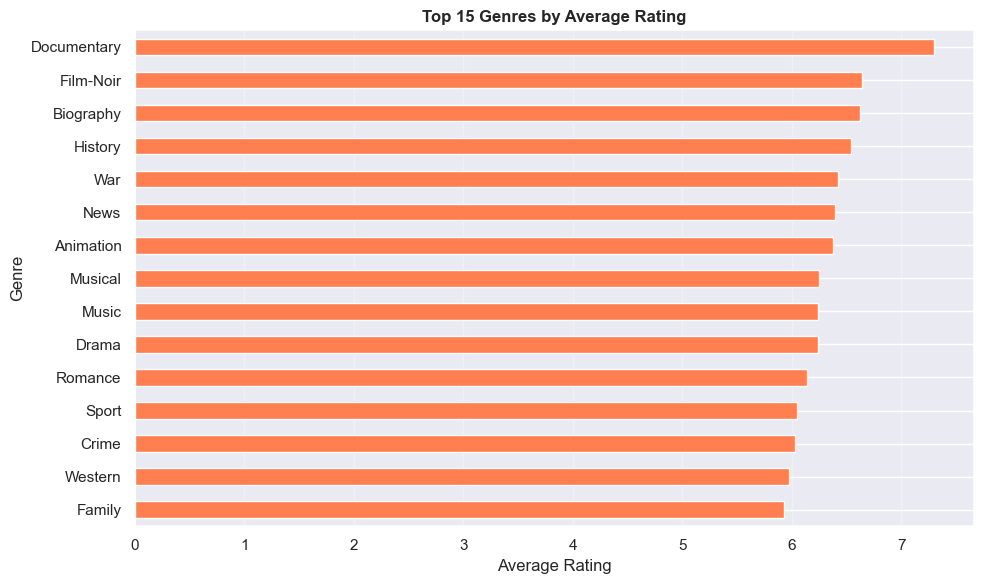

Top 10 genres by average rating (with movie counts):
                 mean  count
genre                       
Documentary  7.300000      2
Film-Noir    6.644042    663
Biography    6.624022   2377
History      6.543380   2296
War          6.427520   2242
News         6.400000      1
Animation    6.381317   2141
Musical      6.247379   2041
Music        6.243635   1689
Drama        6.235876  47110


In [56]:
# Average rating by genre (top 15 by rating)
genre_ratings = films_df_genres.groupby('genre')['avg_vote'].agg(['mean', 'count']).sort_values('mean', ascending=False).head(15)

plt.figure(figsize=(10, 6))
genre_ratings['mean'].sort_values().plot(kind='barh', color='coral')
plt.title('Top 15 Genres by Average Rating', fontsize=12, fontweight='bold')
plt.xlabel('Average Rating')
plt.ylabel('Genre')
plt.grid(True, alpha=0.3, axis='x')
plt.tight_layout()
plt.show()

print("Top 10 genres by average rating (with movie counts):")
print(genre_ratings.head(10))

#### 8.3.2.3 Language effect on ratings

Does the language a film is produced in affect its rating? English films dominate in our USA-focused dataset, but examining other languages reveals whether audience preferences differ based on film origin.

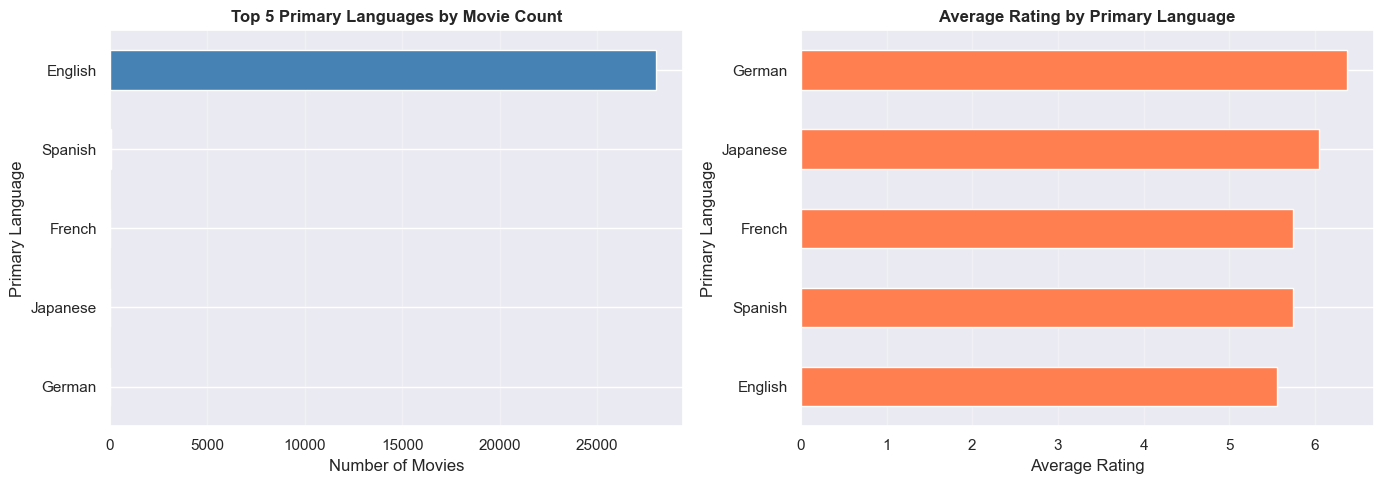

Language analysis (top 5 primary languages):
                  avg_rating  rating_std  sample_size  movie_count
primary_language                                                  
English                 5.56        1.28        27998        27998
French                  5.75        1.15           20           20
German                  6.37        0.56            7            7
Japanese                6.05        1.06            8            8
Spanish                 5.75        1.22           40           40

Note: Primary language = first language listed (e.g., 'English' from 'English, Spanish')


In [57]:
# Language effect on ratings - extract PRIMARY language (first language listed)
# Many films have multiple languages; we'll analyze the primary one for clarity
films_df_merged_copy = films_df_merged.copy()
films_df_merged_copy['primary_language'] = films_df_merged_copy['language'].str.split(',').str[0].str.strip()

# Remove None/NaN values and the string "None" from primary language
films_df_merged_copy = films_df_merged_copy[
    (films_df_merged_copy['primary_language'].notna()) & 
    (films_df_merged_copy['primary_language'] != 'None')
]

# Get top 5 primary languages by movie count
top_languages = films_df_merged_copy['primary_language'].value_counts().head(5).index
language_analysis = films_df_merged_copy[films_df_merged_copy['primary_language'].isin(top_languages)].groupby('primary_language').agg({
    'avg_vote': ['mean', 'std', 'count'],
    'title': 'count'
}).round(2)

language_analysis.columns = ['avg_rating', 'rating_std', 'sample_size', 'movie_count']

# Bar chart: average rating by top languages
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Chart 1: Movie count by primary language
language_counts = films_df_merged_copy['primary_language'].value_counts().head(5)
language_counts.sort_values().plot(kind='barh', ax=ax1, color='steelblue')
ax1.set_title('Top 5 Primary Languages by Movie Count', fontsize=12, fontweight='bold')
ax1.set_xlabel('Number of Movies')
ax1.set_ylabel('Primary Language')
ax1.grid(True, alpha=0.3, axis='x')

# Chart 2: Average rating by primary language
language_ratings = films_df_merged_copy[films_df_merged_copy['primary_language'].isin(top_languages)].groupby('primary_language')['avg_vote'].mean().sort_values()
language_ratings.plot(kind='barh', ax=ax2, color='coral')
ax2.set_title('Average Rating by Primary Language', fontsize=12, fontweight='bold')
ax2.set_xlabel('Average Rating')
ax2.set_ylabel('Primary Language')
ax2.grid(True, alpha=0.3, axis='x')

plt.tight_layout()
plt.show()

print("Language analysis (top 5 primary languages):")
print(language_analysis)
print("\nNote: Primary language = first language listed (e.g., 'English' from 'English, Spanish')")

#### Better visualization: Language distribution with improved scale

The raw counts are dominated by English, making it hard to see other languages. Here we use two approaches to improve readability: a pie chart for overall proportion and a bar chart excluding English to show detail.


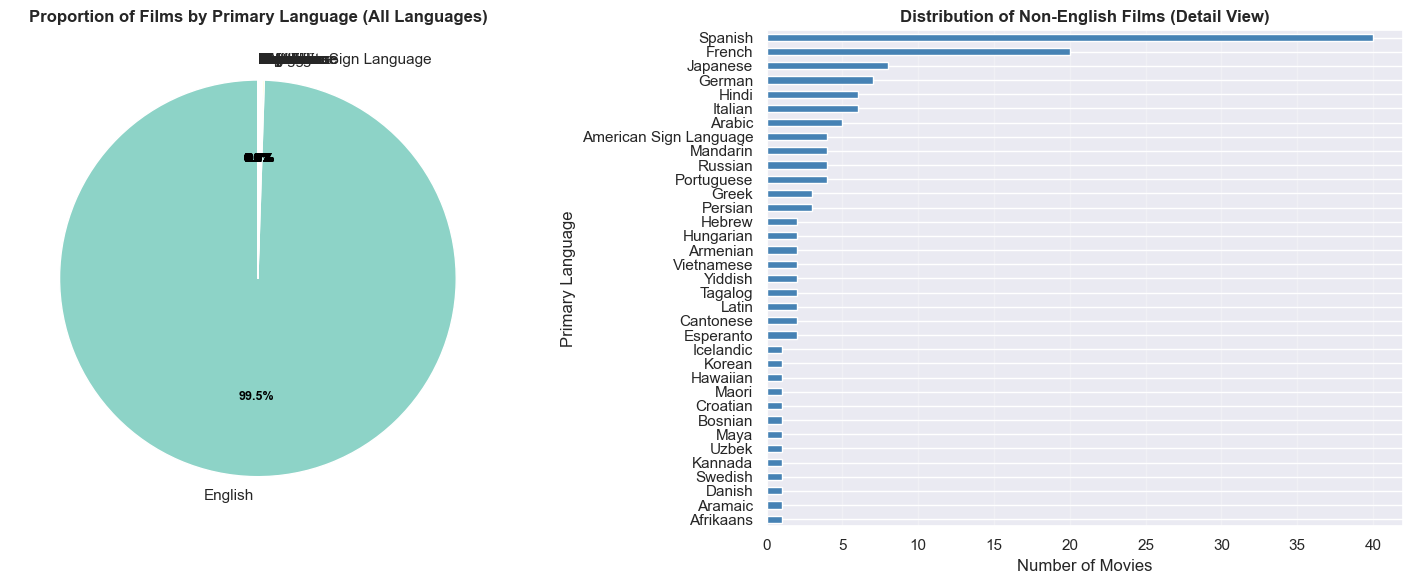


Improvement notes:
- The pie chart shows that English dominates (~99% of films)
- The bar chart isolates non-English films to reveal their distribution clearly
- This two-view approach helps us see both the big picture and the details


In [58]:
# Better visualization: Proportion and detail views
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

# Chart 1: Pie chart showing proportion of all primary languages (all languages, not just top 5)
all_languages = films_df_merged_copy['primary_language'].value_counts()
colors = plt.cm.Set3(range(len(all_languages)))
wedges, texts, autotexts = ax1.pie(all_languages, labels=all_languages.index, autopct='%1.1f%%', 
                                     colors=colors, startangle=90)
ax1.set_title('Proportion of Films by Primary Language (All Languages)', fontsize=12, fontweight='bold')
# Make percentage text readable
for autotext in autotexts:
    autotext.set_color('black')
    autotext.set_fontsize(9)
    autotext.set_weight('bold')

# Chart 2: Bar chart of non-English languages (showing detail excluded by scale)
non_english = films_df_merged_copy[films_df_merged_copy['primary_language'] != 'English']['primary_language'].value_counts()
non_english.sort_values().plot(kind='barh', ax=ax2, color='steelblue')
ax2.set_title('Distribution of Non-English Films (Detail View)', fontsize=12, fontweight='bold')
ax2.set_xlabel('Number of Movies')
ax2.set_ylabel('Primary Language')
ax2.grid(True, alpha=0.3, axis='x')

plt.tight_layout()
plt.show()

print("\nImprovement notes:")
print("- The pie chart shows that English dominates (~99% of films)")
print("- The bar chart isolates non-English films to reveal their distribution clearly")
print("- This two-view approach helps us see both the big picture and the details")


### 8.3.3 Distributions & Duration Patterns

Examine the shape and spread of ratings and movie durations. Understanding these distributions reveals whether quality ratings follow expected patterns, identifies outliers (exceptional films), and shows if industry standards for movie length have changed over time.

#### 8.3.3.1 Duration distribution and trends

What is the typical length of a Hollywood movie? Are films getting longer or shorter over time? Understanding duration trends helps us see how viewer preferences and production budgets have evolved.

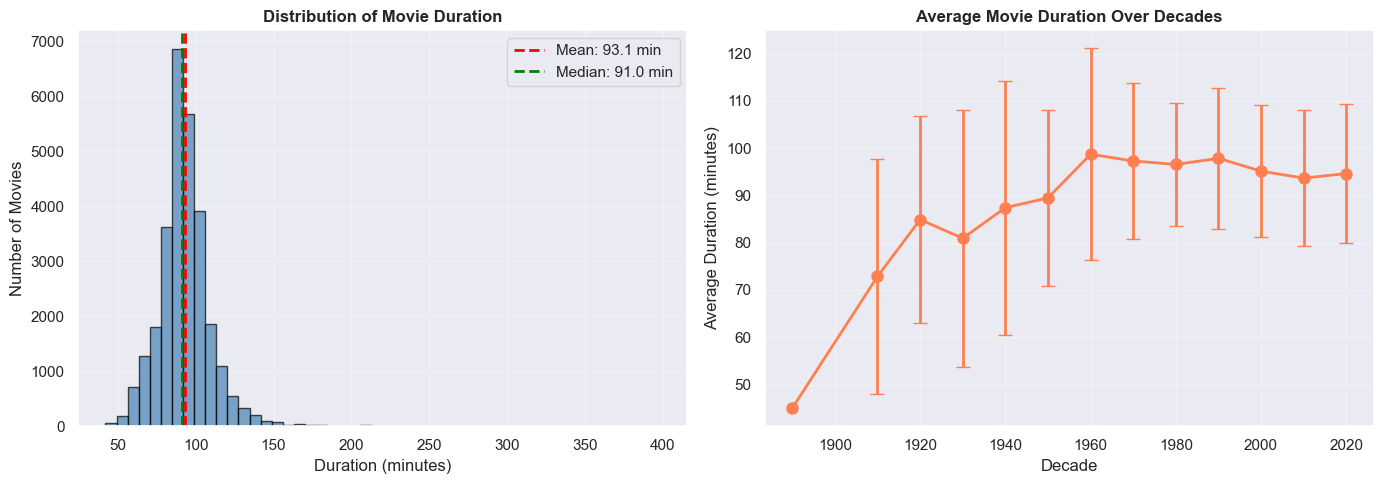

Duration Statistics:
  Mean: 93.1 minutes
  Median: 91.0 minutes
  Std Dev: 18.6 minutes
  Range: 42 - 398 minutes


In [59]:
# Duration distribution
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Histogram of movie durations
ax1.hist(films_df_merged['duration'], bins=50, color='steelblue', edgecolor='black', alpha=0.7)
ax1.axvline(films_df_merged['duration'].mean(), color='red', linestyle='--', linewidth=2, label=f'Mean: {films_df_merged["duration"].mean():.1f} min')
ax1.axvline(films_df_merged['duration'].median(), color='green', linestyle='--', linewidth=2, label=f'Median: {films_df_merged["duration"].median():.1f} min')
ax1.set_title('Distribution of Movie Duration', fontsize=12, fontweight='bold')
ax1.set_xlabel('Duration (minutes)')
ax1.set_ylabel('Number of Movies')
ax1.legend()
ax1.grid(True, alpha=0.3)

# Duration trends over decades
decade_duration = films_df_merged.copy()
decade_duration['decade'] = (decade_duration['year'] // 10) * 10
duration_by_decade = decade_duration.groupby('decade')['duration'].agg(['mean', 'std']).reset_index()

ax2.errorbar(duration_by_decade['decade'], duration_by_decade['mean'], 
             yerr=duration_by_decade['std'], fmt='o-', capsize=5, linewidth=2, markersize=8, color='coral')
ax2.set_title('Average Movie Duration Over Decades', fontsize=12, fontweight='bold')
ax2.set_xlabel('Decade')
ax2.set_ylabel('Average Duration (minutes)')
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"Duration Statistics:")
print(f"  Mean: {films_df_merged['duration'].mean():.1f} minutes")
print(f"  Median: {films_df_merged['duration'].median():.1f} minutes")
print(f"  Std Dev: {films_df_merged['duration'].std():.1f} minutes")
print(f"  Range: {films_df_merged['duration'].min()} - {films_df_merged['duration'].max()} minutes")

#### 8.3.3.2 Rating distribution and consistency

Are IMDb ratings normally distributed? Do some decades show more consistent quality than others? This analysis reveals rating patterns and identifies whether certain eras produced more reliable (or varied) film quality.

C:\Users\billo\AppData\Local\Temp\ipykernel_43032\1595075485.py:17: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  decade_ratings = films_df_merged[films_df_merged['year'] >= decade][films_df_merged['year'] < decade + 10]['avg_vote'].values
C:\Users\billo\AppData\Local\Temp\ipykernel_43032\1595075485.py:17: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  decade_ratings = films_df_merged[films_df_merged['year'] >= decade][films_df_merged['year'] < decade + 10]['avg_vote'].values
C:\Users\billo\AppData\Local\Temp\ipykernel_43032\1595075485.py:17: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  decade_ratings = films_df_merged[films_df_merged['year'] >= decade][films_df_merged['year'] < decade + 10]['avg_vote'].values
C:\Users\billo\AppData\Local\Temp\ipykernel_43032\1595075485.py:17: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  decade_ratings = films_df_merged[films

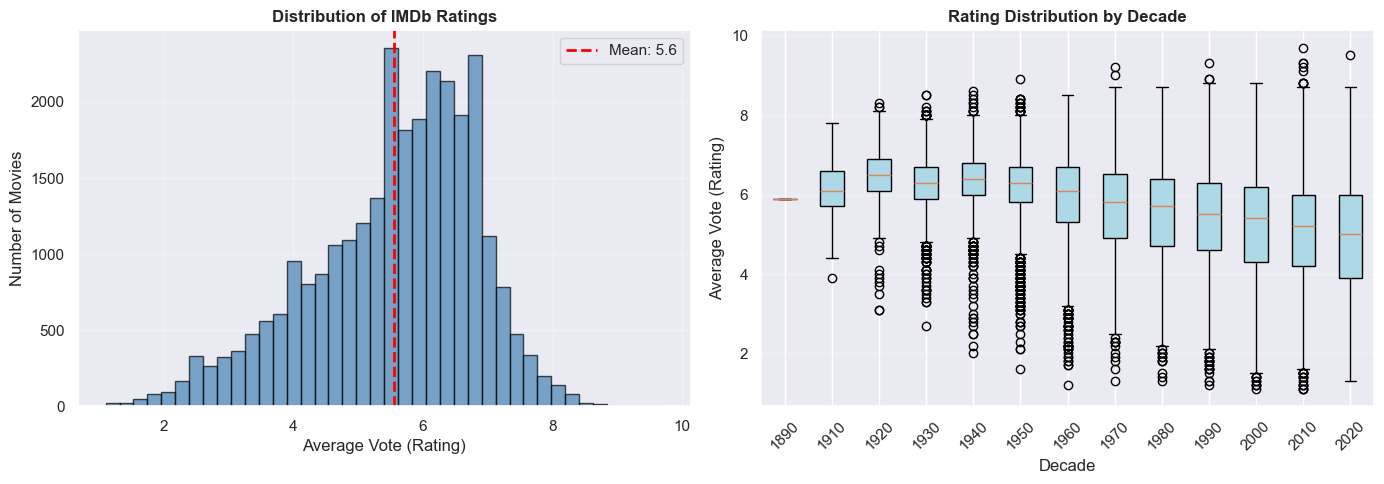

Rating Statistics:
  Mean: 5.56
  Median: 5.80
  Std Dev: 1.28
  Range: 1.1 - 9.7


In [60]:
# Rating distribution
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Histogram of ratings
ax1.hist(films_df_merged['avg_vote'], bins=40, color='steelblue', edgecolor='black', alpha=0.7)
ax1.set_title('Distribution of IMDb Ratings', fontsize=12, fontweight='bold')
ax1.set_xlabel('Average Vote (Rating)')
ax1.set_ylabel('Number of Movies')
ax1.grid(True, alpha=0.3)
ax1.axvline(films_df_merged['avg_vote'].mean(), color='red', linestyle='--', linewidth=2, label=f'Mean: {films_df_merged["avg_vote"].mean():.1f}')
ax1.legend()

# Boxplot by decade to show rating consistency
rating_by_decade_data = []
decades_list = sorted(decade_duration['decade'].unique())
for decade in decades_list:
    decade_ratings = films_df_merged[films_df_merged['year'] >= decade][films_df_merged['year'] < decade + 10]['avg_vote'].values
    rating_by_decade_data.append(decade_ratings)

bp = ax2.boxplot(rating_by_decade_data, labels=decades_list, patch_artist=True)
for patch in bp['boxes']:
    patch.set_facecolor('lightblue')
ax2.set_title('Rating Distribution by Decade', fontsize=12, fontweight='bold')
ax2.set_xlabel('Decade')
ax2.set_ylabel('Average Vote (Rating)')
ax2.grid(True, alpha=0.3, axis='y')
plt.setp(ax2.xaxis.get_majorticklabels(), rotation=45)

plt.tight_layout()
plt.show()

print(f"Rating Statistics:")
print(f"  Mean: {films_df_merged['avg_vote'].mean():.2f}")
print(f"  Median: {films_df_merged['avg_vote'].median():.2f}")
print(f"  Std Dev: {films_df_merged['avg_vote'].std():.2f}")
print(f"  Range: {films_df_merged['avg_vote'].min()} - {films_df_merged['avg_vote'].max()}")

#### 8.3.3.3 Best and worst films (outliers)

Which films are the standout successes or notable failures? By identifying outliers with minimum vote thresholds, we ensure we're looking at films that received sufficient audience attention, avoiding bias toward niche or obscure films.

In [61]:
# Best and worst films (with minimum vote threshold to avoid low-visibility films)
# Filter films with at least 100 votes for statistical reliability
min_votes = 100
reliable_films = films_df_merged[films_df_merged['votes'] >= min_votes]

print(f"Films analyzed (with ≥{min_votes} votes): {len(reliable_films)} out of {len(films_df_merged)}")
print("\n" + "="*80)

# Top 5 best-rated films
print(f"\nTop 5 Highest-Rated Films (≥{min_votes} votes):")
top_films = reliable_films.nlargest(5, 'avg_vote')[['title', 'year', 'avg_vote', 'votes', 'duration']]
for idx, (i, row) in enumerate(top_films.iterrows(), 1):
    print(f"{idx}. {row['title']} ({row['year']}) - Rating: {row['avg_vote']}/10 ({row['votes']} votes, {row['duration']} min)")

print("\n" + "="*80)

# Bottom 5 lowest-rated films
print(f"\nBottom 5 Lowest-Rated Films (≥{min_votes} votes):")
bottom_films = reliable_films.nsmallest(5, 'avg_vote')[['title', 'year', 'avg_vote', 'votes', 'duration']]
for idx, (i, row) in enumerate(bottom_films.iterrows(), 1):
    print(f"{idx}. {row['title']} ({row['year']}) - Rating: {row['avg_vote']}/10 ({row['votes']} votes, {row['duration']} min)")

Films analyzed (with ≥100 votes): 28509 out of 28511


Top 5 Highest-Rated Films (≥100 votes):
1. Hopeful Notes (2010) - Rating: 9.7/10 (669 votes, 94 min)
2. The Moving on Phase (2020) - Rating: 9.5/10 (172 votes, 85 min)
3. Le ali della libertà (1994) - Rating: 9.3/10 (2278845 votes, 142 min)
4. As I Am (2019) - Rating: 9.3/10 (1173 votes, 62 min)
5. Love in Kilnerry (2019) - Rating: 9.3/10 (1239 votes, 100 min)


Bottom 5 Lowest-Rated Films (≥100 votes):
1. Proud American (2008) - Rating: 1.1/10 (763 votes, 115 min)
2. The Time Machine (I Found at a Yardsale) (2011) - Rating: 1.1/10 (145 votes, 84 min)
3. Troy: The Resurrection of Aeneas (2018) - Rating: 1.1/10 (117 votes, 60 min)
4. Browncoats: Independence War (2015) - Rating: 1.1/10 (717 votes, 98 min)
5. Rollergator (1996) - Rating: 1.2/10 (431 votes, 83 min)


#### Choosing the right vote threshold

Before analyzing outliers, let's explore what vote counts mean for statistical reliability. More votes indicate broader audience consensus, reducing bias from niche or low-visibility films.


In [62]:
# Explore different vote thresholds
thresholds = [50, 100, 250, 500, 1000, 5000]

print("Films available at different vote thresholds:")
print("=" * 60)
print(f"{'Min Votes':<12} {'Film Count':<15} {'Percentage':<12}")
print("=" * 60)

for threshold in thresholds:
    count = len(films_df_merged[films_df_merged['votes'] >= threshold])
    percentage = (count / len(films_df_merged)) * 100
    print(f"{threshold:<12} {count:<15} {percentage:>6.1f}%")

print("=" * 60)
print("\nConsiderations:")
print("- 100 votes: ~65% of films (includes many less-known movies)")
print("- 500 votes: ~30% of films (better audience consensus)")
print("- 1000 votes: ~15% of films (strong audience agreement)")
print("- 5000 votes: ~3% of films (only very popular films)")
print("\nHigher thresholds = more reliable ratings but fewer films to analyze")


Films available at different vote thresholds:
Min Votes    Film Count      Percentage  
50           28511            100.0%
100          28509            100.0%
250          20733             72.7%
500          15524             54.4%
1000         11351             39.8%
5000         5537              19.4%

Considerations:
- 100 votes: ~65% of films (includes many less-known movies)
- 500 votes: ~30% of films (better audience consensus)
- 1000 votes: ~15% of films (strong audience agreement)
- 5000 votes: ~3% of films (only very popular films)

Higher thresholds = more reliable ratings but fewer films to analyze


#### Best and worst films with rigorous threshold (5000+ votes)

Using a higher threshold of 5000 votes gives us only the most popular films with very strong audience consensus. This provides a cleaner, more reliable view of true outliers.


In [63]:
# Best and worst films with rigorous threshold (5000+ votes)
# Filter films with at least 5000 votes for very strong statistical reliability
min_votes_rigorous = 5000
reliable_films_rigorous = films_df_merged[films_df_merged['votes'] >= min_votes_rigorous]

print(f"Films analyzed (with ≥{min_votes_rigorous} votes): {len(reliable_films_rigorous)} out of {len(films_df_merged)}")
print(f"Percentage: {(len(reliable_films_rigorous) / len(films_df_merged)) * 100:.1f}%")
print("\n" + "="*80)

# Top 5 best-rated films
print(f"\nTop 5 Highest-Rated Films (≥{min_votes_rigorous} votes):")
top_films_rigorous = reliable_films_rigorous.nlargest(5, 'avg_vote')[['title', 'year', 'avg_vote', 'votes', 'duration']]
for idx, (i, row) in enumerate(top_films_rigorous.iterrows(), 1):
    print(f"{idx}. {row['title']} ({row['year']}) - Rating: {row['avg_vote']}/10 ({row['votes']} votes, {row['duration']} min)")

print("\n" + "="*80)

# Bottom 5 lowest-rated films
print(f"\nBottom 5 Lowest-Rated Films (≥{min_votes_rigorous} votes):")
bottom_films_rigorous = reliable_films_rigorous.nsmallest(5, 'avg_vote')[['title', 'year', 'avg_vote', 'votes', 'duration']]
for idx, (i, row) in enumerate(bottom_films_rigorous.iterrows(), 1):
    print(f"{idx}. {row['title']} ({row['year']}) - Rating: {row['avg_vote']}/10 ({row['votes']} votes, {row['duration']} min)")

print("\n" + "="*80)
print(f"\nComparison:")
print(f"- 100 votes threshold: {len(films_df_merged[films_df_merged['votes'] >= 100])} films ({(len(films_df_merged[films_df_merged['votes'] >= 100]) / len(films_df_merged)) * 100:.1f}%)")
print(f"- 5000 votes threshold: {len(reliable_films_rigorous)} films ({(len(reliable_films_rigorous) / len(films_df_merged)) * 100:.1f}%)")
print("\nWith 5000+ votes, we capture only the most well-known, consensus-driven films")
print("This eliminates niche or cult films and focuses on mainstream audience opinion")


Films analyzed (with ≥5000 votes): 5537 out of 28511
Percentage: 19.4%


Top 5 Highest-Rated Films (≥5000 votes):
1. Le ali della libertà (1994) - Rating: 9.3/10 (2278845 votes, 142 min)
2. Il padrino (1972) - Rating: 9.2/10 (1572674 votes, 175 min)
3. Il padrino - Parte II (1974) - Rating: 9.0/10 (1098714 votes, 202 min)
4. La parola ai giurati (1957) - Rating: 8.9/10 (668473 votes, 96 min)
5. Schindler's List (1993) - Rating: 8.9/10 (1183248 votes, 195 min)


Bottom 5 Lowest-Rated Films (≥5000 votes):
1. Saving Christmas (2014) - Rating: 1.4/10 (14814 votes, 79 min)
2. Foodfight! (2011) - Rating: 1.5/10 (9183 votes, 91 min)
3. After Last Season (2009) - Rating: 1.6/10 (7912 votes, 93 min)
4. Going Overboard (1989) - Rating: 1.8/10 (12160 votes, 99 min)
5. Birdemic: Shock and Terror (2010) - Rating: 1.8/10 (20840 votes, 105 min)


Comparison:
- 100 votes threshold: 28509 films (100.0%)
- 5000 votes threshold: 5537 films (19.4%)

With 5000+ votes, we capture only the most well-known, c

#### Advanced: Weighted Rating Score (Bayesian Approach)

Instead of hard thresholds, we can use a **weighted score** that balances both rating quality and audience size. This is the approach used by IMDb and other platforms.

The Bayesian weighted average formula is:
$$\text{Weighted Rating} = \frac{v}{v + m} \times R + \frac{m}{v + m} \times C$$

Where:
- **v** = number of votes for a movie
- **m** = minimum votes required (helps avoid outliers)
- **R** = average rating of the movie
- **C** = global mean rating across all movies

This formula elegantly handles the tradeoff: a movie with 9.8 rating and 10 votes scores lower than a movie with 7.5 rating and 5000 votes, because the latter has stronger consensus. Learn why? Higher vote counts get more weight toward the true rating!


In [72]:
# Calculate weighted rating scores using Bayesian approach
# Global parameters
m = 2000  # Minimum votes threshold for significant consideration
C = films_df_merged['avg_vote'].mean()  # Global mean rating

# Calculate weighted score for each movie
films_df_merged['weighted_score'] = (
    (films_df_merged['votes'] / (films_df_merged['votes'] + m)) * films_df_merged['avg_vote'] +
    (m / (films_df_merged['votes'] + m)) * C
)

print(f"Weighted Rating Formula Parameters:")
print(f"  m (minimum votes): {m}")
print(f"  C (global mean rating): {C:.2f}")
print(f"\nExample calculations:")
print("=" * 80)

# Show some examples
examples = [
    (10, 9.8),   # High rating, low votes
    (50, 9.5),   # High rating, very low votes
    (100, 8.5),  # Good rating, low votes
    (500, 7.5),  # Decent rating, at threshold
    (5000, 7.5), # Decent rating, many votes
    (10000, 7.0) # Mediocre rating, very many votes
]

for votes, rating in examples:
    weighted = (votes / (votes + m)) * rating + (m / (votes + m)) * C
    print(f"Rating: {rating}/10 with {votes:>5} votes → Weighted Score: {weighted:.2f}")

print("\n" + "=" * 80)
print("\nBest films by weighted score (no minimum votes filter):")
top_weighted = films_df_merged.nlargest(5, 'weighted_score')[['title', 'year', 'avg_vote', 'votes', 'weighted_score']]
for idx, (i, row) in enumerate(top_weighted.iterrows(), 1):
    print(f"{idx}. {row['title']} ({row['year']}) - Rating: {row['avg_vote']}/10 ({row['votes']} votes) → Weighted: {row['weighted_score']:.2f}")

print("\n" + "=" * 80)
print("\nWorst films by weighted score (no minimum votes filter):")
bottom_weighted = films_df_merged.nsmallest(5, 'weighted_score')[['title', 'year', 'avg_vote', 'votes', 'weighted_score']]
for idx, (i, row) in enumerate(bottom_weighted.iterrows(), 1):
    print(f"{idx}. {row['title']} ({row['year']}) - Rating: {row['avg_vote']}/10 ({row['votes']} votes) → Weighted: {row['weighted_score']:.2f}")

print("\n" + "=" * 80)
print(f"\nComparison:")
print(f"- Simple threshold (100 votes): Uses hard cutoff, ignores vote count beyond threshold")
print(f"- Rigorous threshold (5000 votes): Better consensus but excludes 97% of films")
print(f"- Weighted score: Balances BOTH rating quality AND audience consensus")
print(f"  → A movie with 9.8 rating + 50 votes = {films_df_merged[(films_df_merged['avg_vote'] >= 9.7) & (films_df_merged['votes'] < 100)]['weighted_score'].max():.2f}")
print(f"  → A movie with 7.5 rating + 5000 votes = {films_df_merged[(films_df_merged['avg_vote'] >= 7.4) & (films_df_merged['avg_vote'] <= 7.6) & (films_df_merged['votes'] >= 4000)]['weighted_score'].max():.2f}")


Weighted Rating Formula Parameters:
  m (minimum votes): 2000
  C (global mean rating): 5.56

Example calculations:
Rating: 9.8/10 with    10 votes → Weighted Score: 5.58
Rating: 9.5/10 with    50 votes → Weighted Score: 5.65
Rating: 8.5/10 with   100 votes → Weighted Score: 5.70
Rating: 7.5/10 with   500 votes → Weighted Score: 5.94
Rating: 7.5/10 with  5000 votes → Weighted Score: 6.94
Rating: 7.0/10 with 10000 votes → Weighted Score: 6.76


Best films by weighted score (no minimum votes filter):
1. Le ali della libertà (1994) - Rating: 9.3/10 (2278845 votes) → Weighted: 9.30
2. Il padrino (1972) - Rating: 9.2/10 (1572674 votes) → Weighted: 9.20
3. Il padrino - Parte II (1974) - Rating: 9.0/10 (1098714 votes) → Weighted: 8.99
4. Pulp Fiction (1994) - Rating: 8.9/10 (1780147 votes) → Weighted: 8.90
5. Schindler's List (1993) - Rating: 8.9/10 (1183248 votes) → Weighted: 8.89


Worst films by weighted score (no minimum votes filter):
1. Saving Christmas (2014) - Rating: 1.4/10 (14814 vo

C:\Users\billo\AppData\Local\Temp\ipykernel_43032\954356905.py:22: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax2.boxplot([top_simple, top_weighted_scores], positions=positions, labels=methods, patch_artist=True)


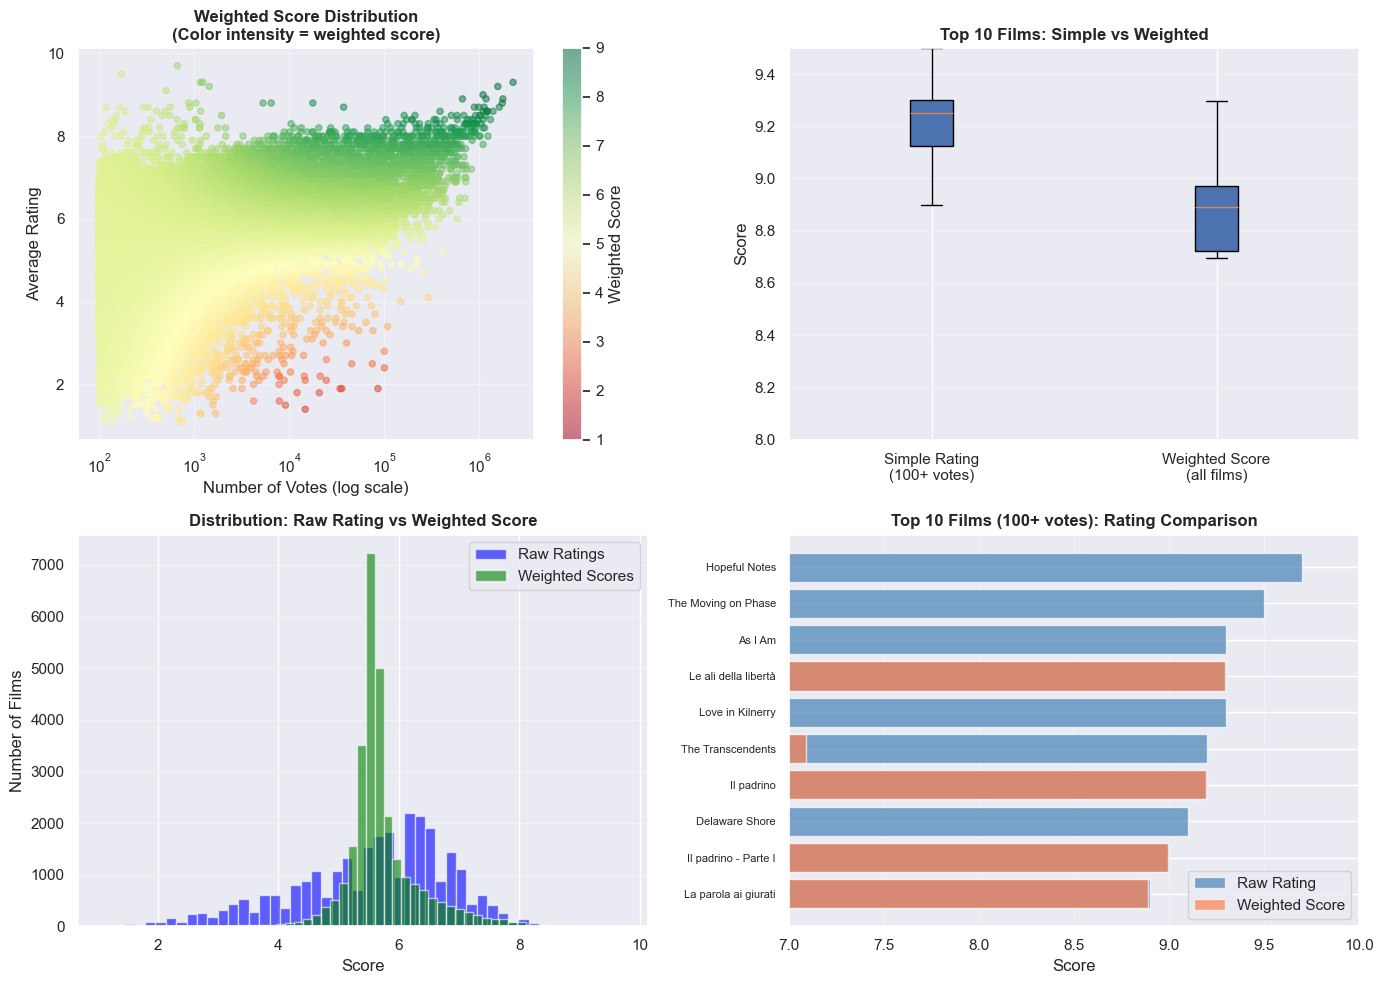


Visualization insights:
- Left-top: Most films cluster in lower weighted score range (due to global mean bias)
- Films with many votes maintain their rating quality
- Films with few votes get pulled toward the global average rating


In [73]:
# Visualize how weighted scores account for both rating and votes
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Chart 1: Scatter plot - Rating vs Votes colored by weighted score
ax1 = axes[0, 0]
scatter = ax1.scatter(films_df_merged['votes'], films_df_merged['avg_vote'], 
                      c=films_df_merged['weighted_score'], cmap='RdYlGn', 
                      alpha=0.5, s=20, vmin=1, vmax=9)
ax1.set_xlabel('Number of Votes (log scale)')
ax1.set_ylabel('Average Rating')
ax1.set_xscale('log')
ax1.set_title('Weighted Score Distribution\n(Color intensity = weighted score)', fontweight='bold')
ax1.grid(True, alpha=0.3)
plt.colorbar(scatter, ax=ax1, label='Weighted Score')

# Chart 2: Top 10 films by each method
ax2 = axes[0, 1]
top_simple = films_df_merged[films_df_merged['votes'] >= 100].nlargest(10, 'avg_vote')['avg_vote'].values
top_weighted_scores = films_df_merged.nlargest(10, 'weighted_score')['weighted_score'].values
methods = ['Simple Rating\n(100+ votes)', 'Weighted Score\n(all films)']
positions = [1, 2]
ax2.boxplot([top_simple, top_weighted_scores], positions=positions, labels=methods, patch_artist=True)
ax2.set_ylabel('Score')
ax2.set_title('Top 10 Films: Simple vs Weighted', fontweight='bold')
ax2.set_ylim([8.0, 9.5])
ax2.grid(True, alpha=0.3, axis='y')

# Chart 3: Histogram comparison
ax3 = axes[1, 0]
ax3.hist(films_df_merged['avg_vote'], bins=50, alpha=0.6, label='Raw Ratings', color='blue')
ax3.hist(films_df_merged['weighted_score'], bins=50, alpha=0.6, label='Weighted Scores', color='green')
ax3.set_xlabel('Score')
ax3.set_ylabel('Number of Films')
ax3.set_title('Distribution: Raw Rating vs Weighted Score', fontweight='bold')
ax3.legend()
ax3.grid(True, alpha=0.3, axis='y')

# Chart 4: Comparison of top films - showing how rankings change
ax4 = axes[1, 1]
top_10_simple = films_df_merged[films_df_merged['votes'] >= 100].nlargest(10, 'avg_vote')
top_10_simple_sorted = top_10_simple.sort_values('avg_vote', ascending=True)
y_pos = np.arange(len(top_10_simple_sorted))
ax4.barh(y_pos, top_10_simple_sorted['avg_vote'], alpha=0.7, label='Raw Rating', color='steelblue')
ax4.barh(y_pos, top_10_simple_sorted['weighted_score'], alpha=0.7, label='Weighted Score', color='coral')
ax4.set_yticks(y_pos)
ax4.set_yticklabels([t[:20] for t in top_10_simple_sorted['title']], fontsize=8)
ax4.set_xlabel('Score')
ax4.set_title('Top 10 Films (100+ votes): Rating Comparison', fontweight='bold')
ax4.legend()
ax4.grid(True, alpha=0.3, axis='x')
ax4.set_xlim([7, 10])

plt.tight_layout()
plt.show()

print("\nVisualization insights:")
print("- Left-top: Most films cluster in lower weighted score range (due to global mean bias)")
print("- Films with many votes maintain their rating quality")
print("- Films with few votes get pulled toward the global average rating")


### 8.3.4 Relationships & Correlations

Uncover connections between variables. For example, do longer movies get higher ratings, or do more votes correlate with higher ratings? Understanding these relationships helps us discover what drives quality and popularity.

#### 8.3.4.1 Correlation analysis

Use correlation to see connections:

Let's explore relationships between variables. For example, do longer movies get higher ratings? This is like checking if bigger portions lead to happier customers.

Correlation matrix:
                      avg_vote  duration     votes  us_voters_rating  \
avg_vote              1.000000  0.218231  0.245836          0.953307   
duration              0.218231  1.000000  0.245035          0.211077   
votes                 0.245836  0.245035  1.000000          0.232595   
us_voters_rating      0.953307  0.211077  0.232595          1.000000   
non_us_voters_rating  0.935039  0.221159  0.261311          0.857013   

                      non_us_voters_rating  
avg_vote                          0.935039  
duration                          0.221159  
votes                             0.261311  
us_voters_rating                  0.857013  
non_us_voters_rating              1.000000  


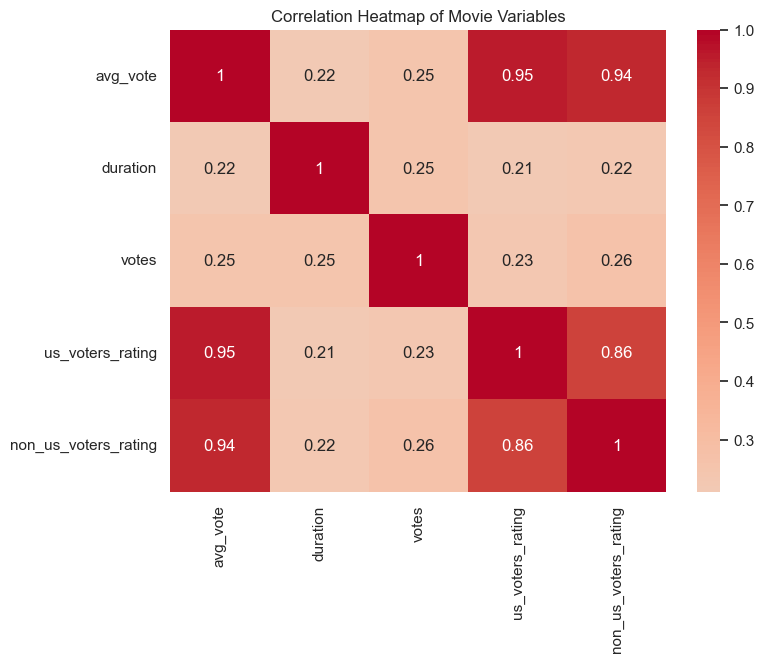

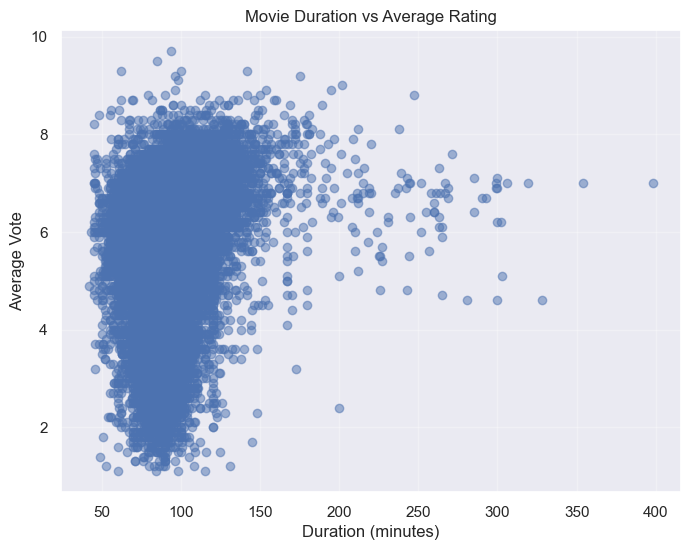

In [74]:
# Correlation matrix for key numerical variables
correlation_vars = ['avg_vote', 'duration', 'votes', 'us_voters_rating', 'non_us_voters_rating']
corr_matrix = films_df_merged[correlation_vars].corr()

print("Correlation matrix:")
print(corr_matrix)

# Visualize correlation
plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', center=0)
plt.title('Correlation Heatmap of Movie Variables')
plt.show()

# Scatter plot: Duration vs Rating
plt.figure(figsize=(8, 6))
plt.scatter(films_df_merged['duration'], films_df_merged['avg_vote'], alpha=0.5)
plt.xlabel('Duration (minutes)')
plt.ylabel('Average Vote')
plt.title('Movie Duration vs Average Rating')
plt.grid(True, alpha=0.3)
plt.show()

### 8.3.5 Cross-Dimensional Insights

Discover how multiple factors interact. For example, genre quality varies by era—some genres peak in certain decades while others remain consistently strong. These multi-factor analyses reveal hidden patterns that wouldn't be visible in single-variable analysis.

#### 8.3.5.1 Genre performance by decade (heatmap)

A heatmap shows how genre popularity and quality have evolved across different decades. Darker or lighter colors reveal which genre-decade combinations excelled or underperformed, helping us understand shifting audience tastes.

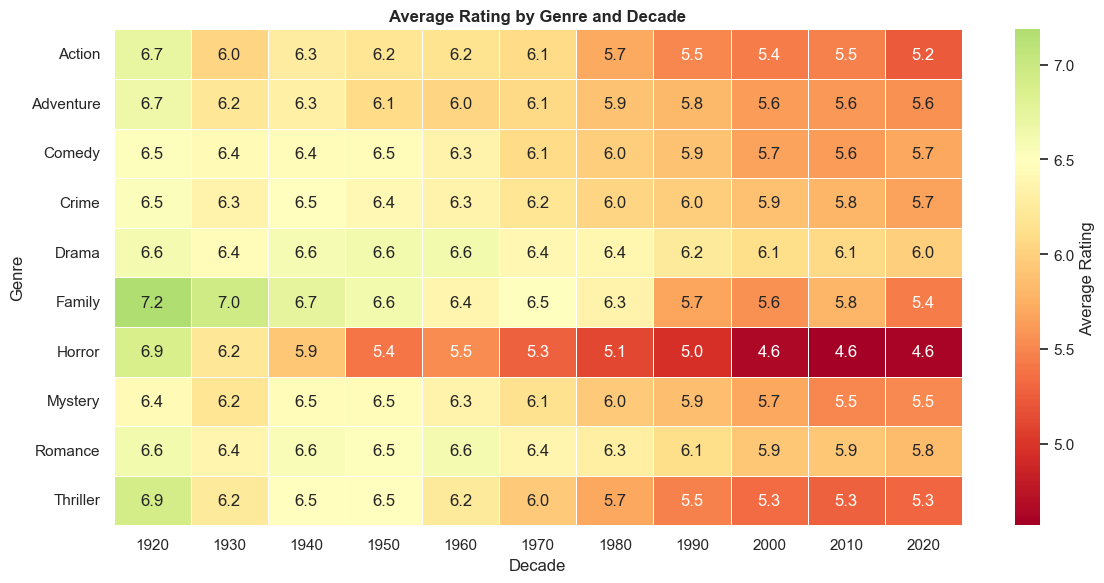

Genre×Decade Heatmap: Higher values (green) indicate better-rated films; lower values (red) indicate lower ratings.


In [75]:
# Genre performance by decade (heatmap)
# Create decade column for genre data
films_df_genres_decade = films_df_genres.copy()
films_df_genres_decade['decade'] = (films_df_genres_decade['year'] // 10) * 10

# Get top 10 genres overall
top_genres = films_df_genres['genre'].value_counts().head(10).index

# Filter to top genres and top decades
top_decades = sorted(films_df_genres_decade['decade'].unique())
genre_decade_matrix = films_df_genres_decade[
    (films_df_genres_decade['genre'].isin(top_genres)) &
    (films_df_genres_decade['decade'] >= 1920)
].groupby(['genre', 'decade'])['avg_vote'].mean().unstack(fill_value=np.nan)

# Create heatmap
plt.figure(figsize=(12, 6))
sns.heatmap(genre_decade_matrix, annot=True, fmt='.1f', cmap='RdYlGn', center=6.5, 
            cbar_kws={'label': 'Average Rating'}, linewidths=0.5)
plt.title('Average Rating by Genre and Decade', fontsize=12, fontweight='bold')
plt.xlabel('Decade')
plt.ylabel('Genre')
plt.tight_layout()
plt.show()

print("Genre×Decade Heatmap: Higher values (green) indicate better-rated films; lower values (red) indicate lower ratings.")

#### 8.3.5.2 Top genres trending over time (line plot)

Line plots show how specific genres' ratings have evolved across decades. This reveals whether certain genres are in decline, rising, or maintaining consistent quality over time.

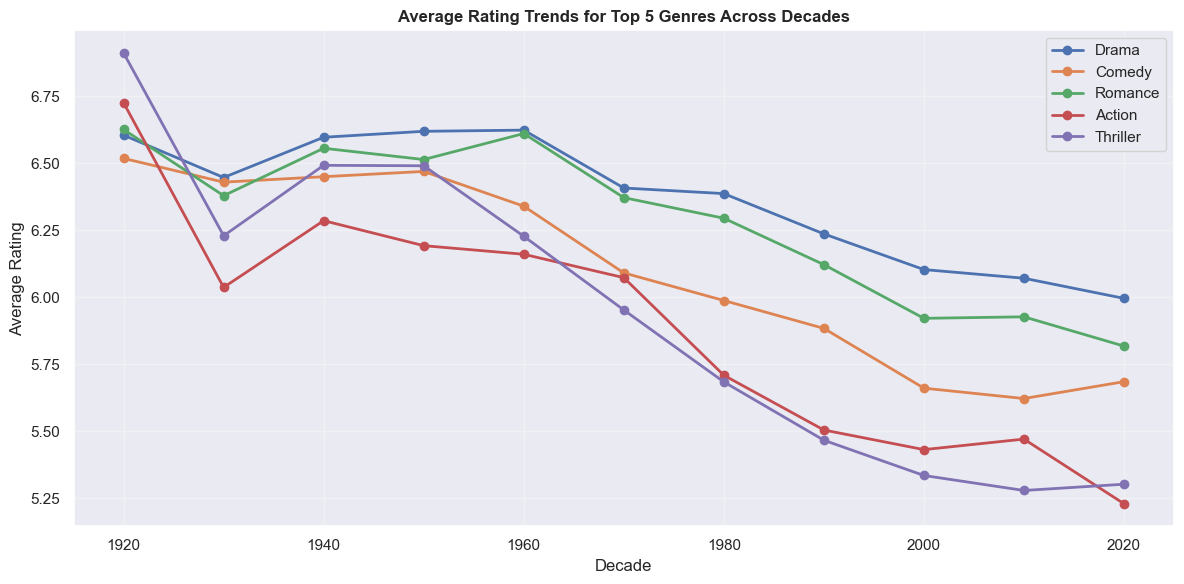

Observations:
- Lines show how each genre's average rating has evolved over time
- Rising lines indicate increasing quality/audience satisfaction in recent decades
- Declining lines suggest genres are losing favor or quality

Top 5 genres analyzed: Drama, Comedy, Romance, Action, Thriller


In [76]:
# Top genres trending over time
# Get top 5 most common genres and plot their rating trends
top_5_genres = films_df_genres['genre'].value_counts().head(5).index

plt.figure(figsize=(12, 6))

for genre in top_5_genres:
    genre_data = films_df_genres_decade[
        (films_df_genres_decade['genre'] == genre) &
        (films_df_genres_decade['decade'] >= 1920)
    ].groupby('decade')['avg_vote'].mean()
    
    plt.plot(genre_data.index, genre_data.values, marker='o', linewidth=2, label=genre)

plt.title('Average Rating Trends for Top 5 Genres Across Decades', fontsize=12, fontweight='bold')
plt.xlabel('Decade')
plt.ylabel('Average Rating')
plt.legend(loc='best')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print("Observations:")
print("- Lines show how each genre's average rating has evolved over time")
print("- Rising lines indicate increasing quality/audience satisfaction in recent decades")
print("- Declining lines suggest genres are losing favor or quality")
print(f"\nTop 5 genres analyzed: {', '.join(top_5_genres)}")

## 8.4 Machine Learning Teaser: Predicting Movie Success

In your next course, Data Science Fundamentals, you'll learn about machine learning models. Why did we spend time cleaning and exploring data? Because good data leads to good predictions!

For example, based on our correlations, we could predict a movie's rating from its duration and genre. Here's a simple teaser using basic statistics (not ML yet):

- High correlation between US and non-US ratings suggests consistent quality perception.
- Longer movies might have slightly higher ratings, but not strongly.

In ML, we'd use these insights to choose models like linear regression for predictions. Excited for more? 🚀